In [6]:
import kagglehub
from utils.config import Config
import platform
from importlib import metadata as importlib_metadata
from pathlib import Path
import json
import os
import shutil
import zipfile
import sys, subprocess, time
config = Config()

In [7]:
cmd = [sys.executable, "-m", "pip", "install", "--disable-pip-version-check", "-r", "requirements.txt"]
print("Running:", " ".join(cmd))
p = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
start = time.time()
for line in p.stdout:
    print(line, end="")
    # safety: si querés cortar a los 3 minutos, descomentá:
    # if time.time() - start > 180:
    #     p.terminate()
    #     break

rc = p.wait()
print("\nReturn code:", rc)

Running: /home/emilio/Desktop/TESIS/.venv/bin/python -m pip install --disable-pip-version-check -r requirements.txt

Return code: 0


In [8]:
def record_environment(packages):
    versions = {}
    for pkg in packages:
        try:
            versions[pkg] = importlib_metadata.version(pkg)
        except importlib_metadata.PackageNotFoundError:
            versions[pkg] = "not_installed"
    info = {
        "python_version": platform.python_version(),
        "platform": platform.platform(),
        "packages": versions,
    }
    config.update({"environment": info})
    print(json.dumps(info, indent=2, ensure_ascii=False))
    return info

record_environment(["tensorflow", "kagglehub", "ipywidgets", "jupyterlab", "tqdm"])

{
  "python_version": "3.12.3",
  "platform": "Linux-6.14.0-37-generic-x86_64-with-glibc2.39",
  "packages": {
    "tensorflow": "2.20.0",
    "kagglehub": "0.4.3",
    "ipywidgets": "8.1.8",
    "jupyterlab": "4.5.3",
    "tqdm": "4.67.3"
  }
}


{'python_version': '3.12.3',
 'platform': 'Linux-6.14.0-37-generic-x86_64-with-glibc2.39',
 'packages': {'tensorflow': '2.20.0',
  'kagglehub': '0.4.3',
  'ipywidgets': '8.1.8',
  'jupyterlab': '4.5.3',
  'tqdm': '4.67.3'}}

In [9]:
def check_cuda_with_gpu():
    try:
        import tensorflow as tf
    except ImportError:
        print("TensorFlow is not installed; unable to check CUDA support.")
        return False
    gpus = tf.config.list_physical_devices('GPU')
    if not gpus:
        print("CUDA is not available or no GPU was detected.")
        config.update({"environment": {"tensorflow_build": {
            "cuda_version": None,
            "cudnn_version": None,
            "gpus_detected": []
        }}})
    build_info = tf.sysconfig.get_build_info()
    cuda_version = build_info.get('cuda_version', 'unknown')
    cudnn_version = build_info.get('cudnn_version', 'unknown')
    gpu_names = []
    for idx, gpu in enumerate(gpus):
        details = tf.config.experimental.get_device_details(gpu)
        name = gpu.name
        gpu_names.append(name)
        print(f"GPU {idx}: {name}")
        print(f"Details: {details}")
    print(f"CUDA version detected by TensorFlow: {cuda_version}")
    print(f"cuDNN version detected by TensorFlow: {cudnn_version}")
    config.update({"environment": {"tensorflow_build": {
        "cuda_version": cuda_version,
        "cudnn_version": cudnn_version,
        "gpus_detected": gpu_names
    }}})
check_cuda_with_gpu()


GPU 0: /physical_device:GPU:0
Details: {'compute_capability': (8, 6), 'device_name': 'NVIDIA GeForce RTX 3060'}
CUDA version detected by TensorFlow: 12.5.1
cuDNN version detected by TensorFlow: 9


In [10]:
def _bytes_to_gb(value):
    return round(value / 1024**3, 2)

def summarize_resources():
    repo_root = Path.cwd()
    cpu_count = os.cpu_count()
    total_ram_gb = None
    if hasattr(os, "sysconf"):
        names = getattr(os, "sysconf_names", {})
        if "SC_PAGE_SIZE" in names and "SC_PHYS_PAGES" in names:
            total_ram_gb = _bytes_to_gb(os.sysconf("SC_PAGE_SIZE") * os.sysconf("SC_PHYS_PAGES"))
    disk = shutil.disk_usage(repo_root)
    print(f"CPUs detected: {cpu_count}")
    if total_ram_gb is not None:
        print(f"Approx. total RAM: {total_ram_gb} GB")
    print(
        f"Disk usage at {repo_root}: total {_bytes_to_gb(disk.total)} GB, free {_bytes_to_gb(disk.free)} GB"
    )

    nvidia_ok = False
    try:
        result = subprocess.run(
            [
                "nvidia-smi",
                "--query-gpu=name,memory.total,memory.free",
                "--format=csv,noheader"
            ],
            capture_output=True,
            text=True,
            check=True,
        )
        print("nvidia-smi output:\n" + result.stdout)
        nvidia_ok = True
    except FileNotFoundError:
        print("nvidia-smi was not found; ensure NVIDIA drivers are installed if you expect GPU support.")
    except subprocess.CalledProcessError as exc:
        print("nvidia-smi returned an error:")
        print(exc.stderr)

    config.update({"environment": {"hardware": {
        "cpu_count": cpu_count,
        "total_ram_gb": total_ram_gb,
        "disk_total_gb": _bytes_to_gb(disk.total),
        "disk_free_gb": _bytes_to_gb(disk.free),
        "repo_root": str(repo_root),
        "nvidia_smi_available": nvidia_ok,
    }}})


summarize_resources()


CPUs detected: 16
Approx. total RAM: 62.68 GB
Disk usage at /home/emilio/Desktop/TESIS: total 382.51 GB, free 62.24 GB
nvidia-smi output:
NVIDIA GeForce RTX 3060, 12288 MiB, 11233 MiB



In [11]:
def prepare_directories(base_data_dir=None):
    repo_root = Path.cwd()
    data_root = Path(base_data_dir) if base_data_dir else Path(config.get("data_root", repo_root / "data"))
    data_root = data_root.expanduser().resolve()
    paths = {
        "raw_data_dir": data_root / "raw",
        "processed_data_dir": data_root / "processed",
        "models_dir": repo_root / "models",
    }
    for path in paths.values():
        path.mkdir(parents=True, exist_ok=True)
    config.update(
        {
            "data_root": str(data_root),
            "paths": {key: str(value) for key, value in paths.items()},
        }
    )
    print("Prepared directories:")
    for key, value in paths.items():
        print(f" - {key}: {value}")
    return paths
prepare_directories()


Prepared directories:
 - raw_data_dir: /home/emilio/Desktop/TESIS/data/raw
 - processed_data_dir: /home/emilio/Desktop/TESIS/data/processed
 - models_dir: /home/emilio/Desktop/TESIS/models


{'raw_data_dir': PosixPath('/home/emilio/Desktop/TESIS/data/raw'),
 'processed_data_dir': PosixPath('/home/emilio/Desktop/TESIS/data/processed'),
 'models_dir': PosixPath('/home/emilio/Desktop/TESIS/models')}

In [12]:
def prepare_local_dataset(dataset_root, raw_dir):
    dataset_root = Path(dataset_root)
    raw_dir = Path(raw_dir)
    raw_dir.mkdir(parents=True, exist_ok=True)

    archives = list(dataset_root.glob("*.zip"))
    if archives:
        for archive in archives:
            with zipfile.ZipFile(archive, 'r') as zf:
                zf.extractall(raw_dir)
            print(f"Extracted {archive.name} into {raw_dir}")
        return raw_dir

    for child in dataset_root.iterdir():
        destination = raw_dir / child.name
        if destination.exists():
            continue
        if child.is_dir():
            try:
                destination.symlink_to(child, target_is_directory=True)
                print(f"Created symlink: {destination} -> {child}")
            except OSError:
                shutil.copytree(child, destination, dirs_exist_ok=True)
                print(f"Copied directory: {destination}")
        else:
            shutil.copy2(child, destination)
            print(f"Copied file: {destination}")
    return raw_dir


def download_dataset(sync_to_raw=True):
    path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
    print("Path to dataset files:", path)
    config.update({"data": {"raw_dataset_source": path}})

    if sync_to_raw:
        raw_dir = Path(config.get("paths", {}).get("raw_data_dir", Path.cwd() / "data" / "raw"))
        prepare_local_dataset(path, raw_dir)
        config.update({"data": {"raw_dataset_path": str(raw_dir)}})
    return path


download_dataset()


Path to dataset files: /home/emilio/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2


'/home/emilio/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2'

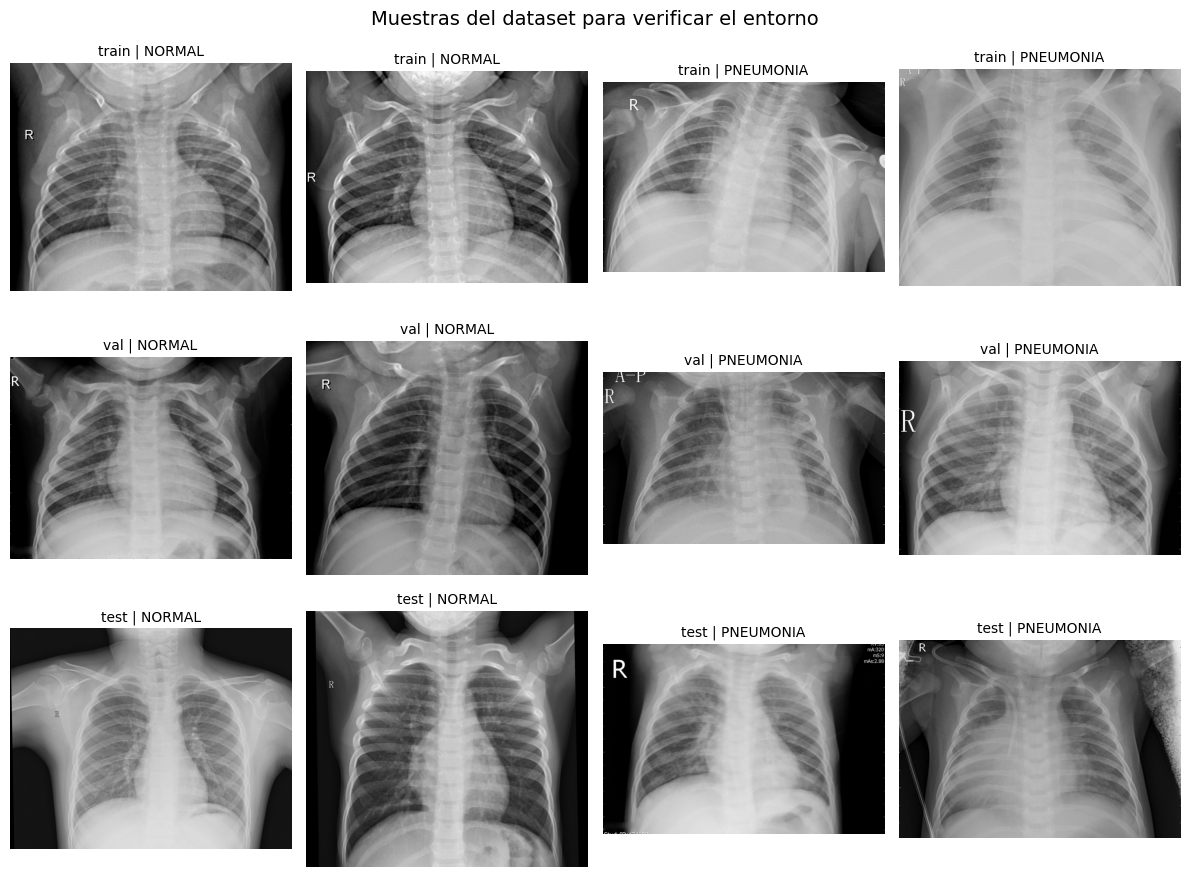

Dataset visualizado desde: /home/emilio/Desktop/TESIS/data/raw/chest_xray


In [13]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image

def _resolve_dataset_root(raw_path: Path) -> Path:
    raw_path = Path(raw_path)
    if not raw_path.exists():
        return raw_path
    if (raw_path / "train").exists():
        return raw_path
    for candidate in raw_path.iterdir():
        if candidate.is_dir() and (candidate / "train").exists():
            return candidate
    return raw_path

raw_dataset_path = Path(config.get("data", {}).get("raw_dataset_path", Path.cwd() / "data" / "raw"))
dataset_root = _resolve_dataset_root(raw_dataset_path)

subsets = ["train", "val", "test"]
classes = ["NORMAL", "PNEUMONIA"]
per_class = 2
samples_rows = []

if not dataset_root.exists():
    print(f"El directorio {dataset_root} no existe. Descargá el dataset antes de visualizar.")
else:
    for subset in subsets:
        subset_samples = []
        for cls in classes:
            cls_dir = dataset_root / subset / cls
            if not cls_dir.exists():
                continue
            candidates = sorted(cls_dir.glob("*.jp*g"))
            if not candidates:
                candidates = sorted(cls_dir.glob("*.png"))
            if not candidates:
                continue
            picks = random.sample(candidates, min(per_class, len(candidates)))
            for path in picks:
                subset_samples.append((cls, path))
        if subset_samples:
            samples_rows.append((subset, subset_samples))

    if not samples_rows:
        print(f"No pude encontrar imágenes en {dataset_root}. ¿Descargaste el dataset?")
    else:
        cols = max(len(samples) for _, samples in samples_rows)
        fig, axes = plt.subplots(len(samples_rows), cols, figsize=(cols * 3, len(samples_rows) * 3))
        if len(samples_rows) == 1:
            axes = [axes]
        if cols == 1:
            axes = [[ax] for ax in axes]
        for row_idx, (subset, samples) in enumerate(samples_rows):
            for col_idx in range(cols):
                ax = axes[row_idx][col_idx]
                ax.axis("off")
                if col_idx >= len(samples):
                    continue
                cls, path = samples[col_idx]
                with Image.open(path) as img:
                    ax.imshow(img, cmap="gray")
                ax.set_title(f"{subset} | {cls}", fontsize=10)
        plt.suptitle("Muestras del dataset para verificar el entorno", fontsize=14)
        plt.tight_layout()
        plt.show()
        print(f"Dataset visualizado desde: {dataset_root}")
